In [1]:
import pandas as pd
import numpy as np

In [2]:
df_pay = pd.read_csv("data/03 Оплаты ХК.csv", sep=";")

In [3]:
from general_information import read_actions, read_balances, read_payments
actions = read_actions()
payments = read_payments()
balance = read_balances()


In [4]:
df_pay.head()

,Номер,Дата оплаты,Сумма,Способ оплаты
0,15,24.01.2025,100,5.0
1,15,25.01.2026,1240,5.0
2,15,25.05.2025,"293,96",5.0
3,15,25.06.2025,10,5.0
4,15,26.02.2025,"289,56",5.0


In [5]:
df_pay.groupby(by="Номер",as_index=False).agg({"Сумма": "count"})

,Номер,Сумма
0,15,16
1,16,15
2,17,13
3,18,15
4,20,13
...,...,...
128717,147099,16
128718,147100,14
128719,147101,15
128720,147102,15


In [6]:
from form_time_features import extract_payment_features

payment_features = extract_payment_features(payments, k=3, current_date=pd.to_datetime('2026-04-23'))
print(df_pay['Номер'].unique().shape, payment_features.shape)
print(f"Число неплатёжников: {(payment_features['Платежей_за_последние_3_мес'] == 0).sum()}")
payment_features.head()

(128722,) (128722, 3)
Число неплатёжников: 14205


,Номер,Дней_с_последнего_платежа,Платежей_за_последние_3_мес
0,15,26,3
1,16,36,2
2,17,42,1
3,18,39,2
4,20,40,1


In [7]:
from form_time_features import calculate_complex_features

complex_features = calculate_complex_features(payments, balance, k=3, curr_date=pd.to_datetime('2026-01-23'))
complex_features.head()

e:\git\neuro\hackaton\form_time_features.py:129: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  paid_fraction = last_12m_df.groupby('ЛС').apply(


,Id,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Balance_Trend_Slope_3M,Current_Debt,Debt_to_Avg_Accrual_3M,Days_Since_Advance_5th,Days_Since_Salary_20th
0,1,9999.0,0.0,0,1.0,0.0,0.0,0.0,18,3
1,2,9999.0,0.0,0,1.0,0.0,0.0,0.0,18,3
2,3,9999.0,0.0,0,1.0,0.0,0.0,0.0,18,3
3,4,9999.0,0.0,0,1.0,0.0,0.0,0.0,18,3
4,5,9999.0,0.0,0,1.0,0.0,0.0,0.0,18,3


In [8]:
complex_features_cut = complex_features[complex_features['Days_Since_Clearance'] != 9999]
print(complex_features_cut.shape)
complex_features_cut.head()

(108584, 10)


,Id,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Balance_Trend_Slope_3M,Current_Debt,Debt_to_Avg_Accrual_3M,Days_Since_Advance_5th,Days_Since_Salary_20th
14,15,-2.0,1.000000,0,1.174883,-295.383,1137.99,-0.080980,18,3
15,16,9.0,1.000000,0,0.608088,130.330,-563.78,-1.714138,18,3
16,17,9.0,0.833333,0,1.000353,-57.430,0.00,0.000000,18,3
17,18,8.0,1.000000,0,1.000000,0.000,0.00,0.000000,18,3
19,20,11.0,0.916667,0,1.264409,-28.068,-83.16,-0.695318,18,3


In [9]:
complex_features_cut["debt_current"] = 1

C:\Users\ArtemyPC\AppData\Local\Temp\ipykernel_14176\1686362469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complex_features_cut["debt_current"] = 1


In [19]:
from form_time_features import actions_features


act_feat = actions_features(complex_features_cut, actions, payments, balance, check_date='2025-11-23')
act_feat.iloc[:,8:].head()
# act_feat.columns

,Days_Since_Advance_5th,Days_Since_Salary_20th,debt_current,debt_start_date,paid_after_k_days,target,days_since_E-mail,days_since_Автодозвон,days_since_Выезд к абоненту,days_since_Заявление о выдаче судебного приказа,...,success_rate_Автодозвон,success_rate_E-mail,success_rate_СМС,success_rate_Обзвон оператором,success_rate_Претензия,success_rate_Выезд к абоненту,success_rate_Уведомление о введении ограничения,success_rate_Ограничение,success_rate_Заявление о выдаче судебного приказа,success_rate_Получение судебного приказа или ИЛ
0,18,3,1,2025-11-25,1400.00,1.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
1,18,3,1,2025-11-14,0.00,-0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
2,18,3,1,2025-11-14,0.00,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
3,18,3,1,2025-11-15,0.00,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
4,18,3,1,2025-11-12,159.91,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635


(array([  29.,   16.,   17.,   13.,   15.,   10.,    7.,   12.,   10.,
           8.,   10.,   14.,   10.,   13.,   11.,   13.,   16.,   12.,
          10.,   19.,   10.,    7.,   15.,    5.,   16.,   12.,   12.,
          11.,    9.,    8.,   16.,   17.,   10.,   27.,   27.,   25.,
          20.,   12.,   18.,   15.,   18.,   22.,   21.,   20.,   18.,
          21.,   24.,   11.,   14.,   14.,   19.,   20.,   22.,   14.,
          29.,   25.,   20.,   20.,   24.,   25.,   15.,   25.,   34.,
          26.,   24.,   21.,   30.,   63.,   36., 2269.]),
 array([0.0104526 , 0.02458899, 0.03872538, 0.05286177, 0.06699816,
        0.08113455, 0.09527095, 0.10940734, 0.12354373, 0.13768012,
        0.15181651, 0.1659529 , 0.1800893 , 0.19422569, 0.20836208,
        0.22249847, 0.23663486, 0.25077125, 0.26490764, 0.27904404,
        0.29318043, 0.30731682, 0.32145321, 0.3355896 , 0.34972599,
        0.36386238, 0.37799878, 0.39213517, 0.40627156, 0.42040795,
        0.43454434, 0.44868073, 0.46

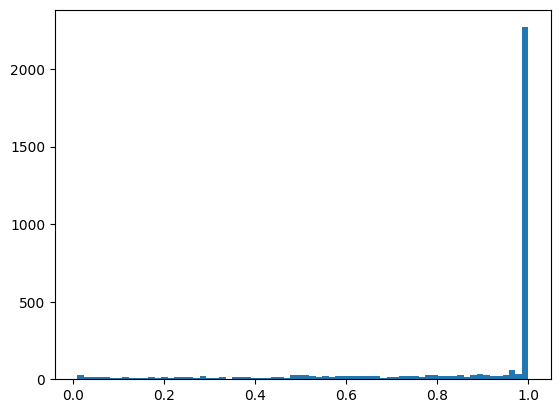

In [20]:
import matplotlib.pyplot as plt

plt.hist(act_feat[act_feat.target > 0.01].target, bins = 70)

In [ ]:
act_feat.columns

In [ ]:
# Проверка число сезонных признаков
from form_time_features import get_seasonality_features

current_date=pd.to_datetime('2026-04-23')
df_season = get_seasonality_features(current_date)
df_season.head()

In [ ]:
import pandas as pd
import os

# путь к главному файлу
main_file = "data/14 Лимиты мер воздействия ХК.xlsx"

# читаем главный файл
limits_df = pd.read_excel(main_file)

# словарь для результатов
result = {}

for _, row in limits_df.iterrows():
    file_name = row.iloc[0]
    limit = row.iloc[1]

    # пропускаем пустые строки
    if pd.isna(file_name):
        continue

    file_path = os.path.join("data", file_name+".xlsx")

    # читаем файл без заголовков
    df_raw = pd.read_excel(file_path, header=None)

    # 1 строка — название операции
    operation_name = df_raw.iloc[0, 0]

    # 2 строка — заголовки
    df = df_raw.iloc[2:].copy()
    df.columns = df_raw.iloc[1]

    # чистка: убираем #Н/Д
    df = df[df["ЛС"].notna()]

    # сохраняем
    result[operation_name] = {
        "limit": limit,
        "data": df
    }

# теперь result — словарь с данными

In [ ]:
result.keys()

In [ ]:
result["Заявление о выдаче судебного приказа"]

In [ ]:
df2 = pd.read_excel("data/01 Общая информация о ЛС ХК.xlsx", index_col=0)
df2.drop(columns=["Адрес (ГУИД)"], inplace=True)
df2

In [ ]:
from general_information import read_general_information, read_balances, read_actions
from form_time_features import calculate_complex_features
import pandas as pd
# Читаем сальдовую ведомость и удаляем из неё нулевые строки
balances = read_balances()
cols_to_check = balances.columns.drop('ЛС')
balances = balances[(balances[cols_to_check] != 0).any(axis=1)]

# Все другие таблицы должны соответствовать данным id.
ids = balances['ЛС']

# Читаем платёжную таблицу. Удаляем лишние id.
df_pay = pd.read_csv("data/03 Оплаты ХК.csv", sep=";", decimal=",")
df_pay = df_pay[df_pay['Номер'].isin(ids)]

# Читаем информацию с булевыми признаками. Удаляем лишние id.
general_df = read_general_information()
general_df = general_df[general_df['ЛС'].isin(ids)]

actions_df = read_actions()

df = calculate_complex_features(df_pay, general_df, 3, pd.Timestamp("2025-04-01"))
df

ValueError: cannot convert float NaN to integer

In [1]:
from form_train_set import build_master_dataset

df = build_master_dataset(12)

df

Начинаем сборку панельных данных с шагом 12 мес. от 2025-04-01 до 2026-04-23
Обработка среза на дату: 2025-04-01...


e:\git\neuro\hackaton\form_time_features.py:129: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  paid_fraction = last_12m_df.groupby('ЛС').apply(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136781 entries, 0 to 136780
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ЛС                        136781 non-null  int32         
 1   Days_Since_Clearance      136781 non-null  float64       
 2   Payment_Fraction_12M      136781 non-null  float64       
 3   Consecutive_Debt_Months   136781 non-null  int32         
 4   Payment_Accrual_Ratio_kM  136781 non-null  float64       
 5   Balance_Trend_Slope_12M   136781 non-null  float64       
 6   Current_Debt              69212 non-null   float64       
 7   Debt_to_Avg_Accrual_3M    136781 non-null  float64       
 8   Days_Since_Advance_5th    136781 non-null  int64         
 9   Days_Since_Salary_20th    136781 non-null  int64         
 10  debt_start_date           136781 non-null  datetime64[ns]
 11  paid_after_k_days         136781 non-null  float64       
dtypes:

e:\git\neuro\hackaton\form_time_features.py:129: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  paid_fraction = last_12m_df.groupby('ЛС').apply(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136781 entries, 0 to 136780
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ЛС                        136781 non-null  int32         
 1   Days_Since_Clearance      136781 non-null  float64       
 2   Payment_Fraction_12M      136781 non-null  float64       
 3   Consecutive_Debt_Months   136781 non-null  int32         
 4   Payment_Accrual_Ratio_kM  136781 non-null  float64       
 5   Balance_Trend_Slope_12M   136781 non-null  float64       
 6   Current_Debt              69744 non-null   float64       
 7   Debt_to_Avg_Accrual_3M    136781 non-null  float64       
 8   Days_Since_Advance_5th    136781 non-null  int64         
 9   Days_Since_Salary_20th    136781 non-null  int64         
 10  debt_start_date           136781 non-null  datetime64[ns]
 11  paid_after_k_days         136781 non-null  float64       
dtypes:

,Id,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Balance_Trend_Slope_12M,Current_Debt,Debt_to_Avg_Accrual_3M,Days_Since_Advance_5th,Days_Since_Salary_20th,...,Почта России квитанция,электронная квитанция,не проживает,ЧД,МКД,Общежитие,Установка Тамбур,Установка опора,Установка в квартире/доме,Установка лестничкая клетка
0,15,6.0,1.000000,0,0.846768,83.745000,-63.45,-0.116097,27,12,...,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет,Нет
1,16,20.0,1.000000,0,1.327165,-86.280000,-1305.80,-4.951464,27,12,...,Нет,Нет,Нет,Нет,Да,Нет,Да,Нет,Нет,Нет
2,17,37.0,0.666667,1,0.309917,289.745000,579.49,1.380165,27,12,...,Нет,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Да
3,18,16.0,1.000000,0,1.000000,0.000000,NaN,0.000000,27,12,...,Нет,Нет,Нет,Да,Нет,Нет,Нет,Нет,Нет,Нет
4,20,25.0,1.000000,0,1.000000,0.000000,NaN,0.000000,27,12,...,Нет,Нет,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257439,147099,17.0,0.916667,0,1.046312,-47.305989,-518.01,-0.388764,27,12,...,Да,Да,Нет,Да,Нет,Нет,Нет,Нет,Нет,Нет
257440,147100,22.0,0.916667,0,1.000121,33.074505,NaN,0.000000,27,12,...,Нет,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет
257441,147101,18.0,1.000000,0,1.012096,12.294890,-2835.66,-1.102869,27,12,...,Да,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет
257442,147102,19.0,1.000000,0,1.000000,0.000000,NaN,0.000000,27,12,...,Да,Нет,Нет,Да,Нет,Нет,Нет,Да,Нет,Нет
